In [1]:
import scipy.io as sio
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [35]:
def prepare_data(mat):
    data = sio.loadmat(mat)
    reponses_neuronales = data['stim'][0]['resp'][0] 
    identites_stimuli = data['stim'][0]['istim'][0].flatten()

    # ==========================================
    # 1. ISOLATE SPONTANEOUS ACTIVITY (WHITE NOISE)
    # ==========================================
    masque_spontane = identites_stimuli > 2800 
    X_spont = reponses_neuronales[masque_spontane]

    scaler = StandardScaler()
    X_spont_z = scaler.fit_transform(X_spont) 

    pca_spont = PCA(n_components=32)
    pca_spont.fit(X_spont_z) 
    axes_bruit = pca_spont.components_ 

    # ==========================================
    # 2. EXTRACT AND Z-SCORE VISUAL RESPONSES
    # ==========================================
    masque_images = identites_stimuli <= 2800
    ids_valides = identites_stimuli[masque_images] 
    reponses_valides = reponses_neuronales[masque_images]

    reponses_valides_z = scaler.transform(reponses_valides) 

    # ==========================================
    # 3. SPLIT: 1ST OCCURRENCE vs MEAN OF ALL OTHERS
    # ==========================================
    unique_ids, counts = np.unique(ids_valides, return_counts=True)
    
    # Only keep stimuli that were shown AT LEAST twice
    stimuli_communs = unique_ids[counts >= 2]
    
    X1_list = []
    X2_list = []
    final_ids = []
    
    for stim_id in stimuli_communs:
        # Get all temporal indices where this specific image was shown
        all_indices = np.where(ids_valides == stim_id)[0]
        
        # X1 gets the exact FIRST occurrence
        X1_list.append(reponses_valides_z[all_indices[0]])
        
        # X2 gets the MEAN of ALL SUBSEQUENT occurrences (from index 1 to the end)
        # This reduces trial-to-trial noise and creates a highly robust test sample
        mean_of_others = np.mean(reponses_valides_z[all_indices[1:]], axis=0)
        X2_list.append(mean_of_others)
        
        final_ids.append(stim_id)
        
    # Convert lists back to matrices
    X1_z = np.array(X1_list)
    X2_z = np.array(X2_list)
    final_ids = np.array(final_ids)

    # Note: final_ids is returned twice because train_ids and test_ids are now identical
    return X1_z, X2_z, axes_bruit, final_ids, final_ids

In [36]:
def clean_spontaneous_activity(X, axes_bruit):
    X1_z, X2_z = X
    projection_bruit_X1 = np.dot(X1_z, axes_bruit.T) #Projection of the training set on the noise axes
    projection_bruit_X2 = np.dot(X2_z, axes_bruit.T) #Projection of the test set on the noise axes

    bruit_reconstruit_X1 = np.dot(projection_bruit_X1, axes_bruit) #Reconstruction of the noise in the training set
    bruit_reconstruit_X2 = np.dot(projection_bruit_X2, axes_bruit) #Reconstruction of the noise in the test set

    X1_clean = X1_z - bruit_reconstruit_X1 #Subtraction of the noise from the training set
    X2_clean = X2_z - bruit_reconstruit_X2 #Subtraction of the noise from the test set
    return X1_clean, X2_clean

In [49]:

def PCA_cvPCA(X1_clean, X2_clean,n_components=None):
    pca_signal = PCA(n_components=n_components)
    pca_signal.fit(X1_clean) #perform PCA on the training set to get the signal axes

    projection_1 = pca_signal.transform(X1_clean) #Projection of the training set on the signal axes
    projection_2 = pca_signal.transform(X2_clean) #Projection of the test set on the signal axes

    variance_cvpca = np.mean(projection_1 * projection_2, axis=0) #compute the variance as in classic PCA 
    variance_cvpca = np.maximum(variance_cvpca, 1e-10)
    return variance_cvpca,pca_signal, projection_1, projection_2



In [50]:
def normalize_population_vectors(mat):
    """need to normalize the population vectors before computing the correlation matrix for the nearest neighbor decoder"""
    mat_centered = mat - np.mean(mat, axis=1, keepdims=True)
    norm = np.linalg.norm(mat_centered, axis=1, keepdims=True)
    norm[norm == 0] = 1e-10
    return mat_centered / norm

In [51]:
def decoder_nearest_neighbor_PC(projection_1, projection_2, train_ids, test_ids):


    #normalization of the train et test sets 
    train_norm = normalize_population_vectors(projection_1)
    test_norm = normalize_population_vectors(projection_2)

    # 3. Calcul de la matrice de corrélation
    # Ligne i = essai de test, Colonne j = essai d'entraînement
    correlation_matrix = np.dot(test_norm, train_norm.T)

    # 4. PRÉDICTION AVEC MAPPING DES IDs
    # On cherche l'indice de la colonne (entraînement) qui a le plus haut score
    best_match_indices = np.argmax(correlation_matrix, axis=1)

    # On convertit cet indice matriciel (0 à 2365) en véritable ID du stimulus
    predicted_ids = train_ids[best_match_indices]

    # Les vraies cibles sont simplement les IDs du set de test
    vraies_cibles = test_ids

    # 5. Calcul du score exact
    bonnes_predictions = np.sum(predicted_ids == vraies_cibles)
    precision = bonnes_predictions / len(test_ids)
    return precision



In [ ]:
def decoder_nearest_neighbor(X1,X2, train_ids, test_ids):
    
    # 1. Normaliser les vecteurs de population des deux passages
    train_norm = normalize_population_vectors(X1)
    test_norm = normalize_population_vectors(X2)

    # 2. Matrice de corrélation (2366 images test VS 2366 images train)
    correlation_matrix = np.dot(test_norm, train_norm.T)

    best_match_indices = np.argmax(correlation_matrix, axis=1)
    predicted_ids = train_ids[best_match_indices]

    # Les vraies cibles sont simplement les IDs du set de test
    vraies_cibles = test_ids

    # 5. Calcul du score exact
    bonnes_predictions = np.sum(predicted_ids == vraies_cibles)
    precision = bonnes_predictions / len(test_ids)
    return precision


In [52]:
X1_z, X2_z, axes_bruit, train_ids, test_ids = prepare_data('6845348/natimg2800_M170714_MP032_2017-08-07.mat') #exemple with one mouse 
X1_clean, X2_clean = clean_spontaneous_activity((X1_z, X2_z), axes_bruit) #clean neural data with first functions 
variance_cvpca, pca_signal, projection_1, projection_2 = PCA_cvPCA(X1_clean, X2_clean) #perform cvPCA on the cleaned data

precision = decoder_nearest_neighbor_PC(projection_1, projection_2,train_ids, test_ids)
print(f"Précision du décodage (Nearest-Neighbor) : {precision * 100:.2f}%")

Précision du décodage (Nearest-Neighbor) : 27.18%


In [ ]:
files = ['6845348/natimg2800_M160825_MP027_2016-12-14.mat','6845348/natimg2800_M161025_MP030_2017-05-29.mat','6845348/natimg2800_M170604_MP031_2017-06-28.mat','6845348/natimg2800_M170714_MP032_2017-08-07.mat','6845348/natimg2800_M170714_MP032_2017-09-14.mat','6845348/natimg2800_M170717_MP033_2017-08-20.mat','6845348/natimg2800_M170717_MP034_2017-09-11.mat']
precisions_PC=[]
precisions=[]
for file in files:
    X1_z, X2_z, axes_bruit, train_ids, test_ids = prepare_data(file)
    X1_clean, X2_clean = clean_spontaneous_activity((X1_z, X2_z), axes_bruit)
    variance_cvpca, pca_signal, projection_1, projection_2 = PCA_cvPCA(X1_clean, X2_clean)
    precision_PC = decoder_nearest_neighbor_PC(projection_1, projection_2,train_ids, test_ids)
    precision = decoder_nearest_neighbor(X1_z, X2_z,train_ids, test_ids)
    precisions_PC.append(precision_PC)
    precisions.append(precision)
    print(f"Précision du décodage (Nearest-Neighbor with PCA) : {precision_PC * 100:.2f}%")
    print(f"Précision du décodage (Nearest-Neighbor) : {precision * 100:.2f}%")
print(f"Moyenne PCA : {np.mean(precisions_PC) * 100:.2f}%, Écart-type PCA : {np.std(precisions_PC) * 100:.2f}%,Mediane PCA : {np.median(precisions_PC) * 100:.2f}%")
print(f"Moyenne : {np.mean(precisions) * 100:.2f}%, Écart-type : {np.std(precisions) * 100:.2f}%,Mediane : {np.median(precisions) * 100:.2f}")


Précision du décodage (Nearest-Neighbor with PCA) : 31.15%
Précision du décodage (Nearest-Neighbor) : 37.40%
Précision du décodage (Nearest-Neighbor with PCA) : 30.77%
Précision du décodage (Nearest-Neighbor) : 30.77%
Précision du décodage (Nearest-Neighbor with PCA) : 36.71%
Précision du décodage (Nearest-Neighbor) : 38.96%
Précision du décodage (Nearest-Neighbor with PCA) : 27.11%
Précision du décodage (Nearest-Neighbor) : 31.29%
Précision du décodage (Nearest-Neighbor with PCA) : 50.57%
Précision du décodage (Nearest-Neighbor) : 49.36%
Précision du décodage (Nearest-Neighbor with PCA) : 70.39%
Précision du décodage (Nearest-Neighbor) : 75.68%
Précision du décodage (Nearest-Neighbor with PCA) : 58.68%
Précision du décodage (Nearest-Neighbor) : 58.68%
Moyenne PCA : 43.63%, Écart-type PCA : 15.27%,Mediane PCA : 36.71%
Moyenne : 46.02%, Écart-type : 15.23%,Mediane : 38.96


Calcul des 4 conditions en cours...


c:\Users\33673\anaconda3\envs\human_cognition\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\33673\anaconda3\envs\human_cognition\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


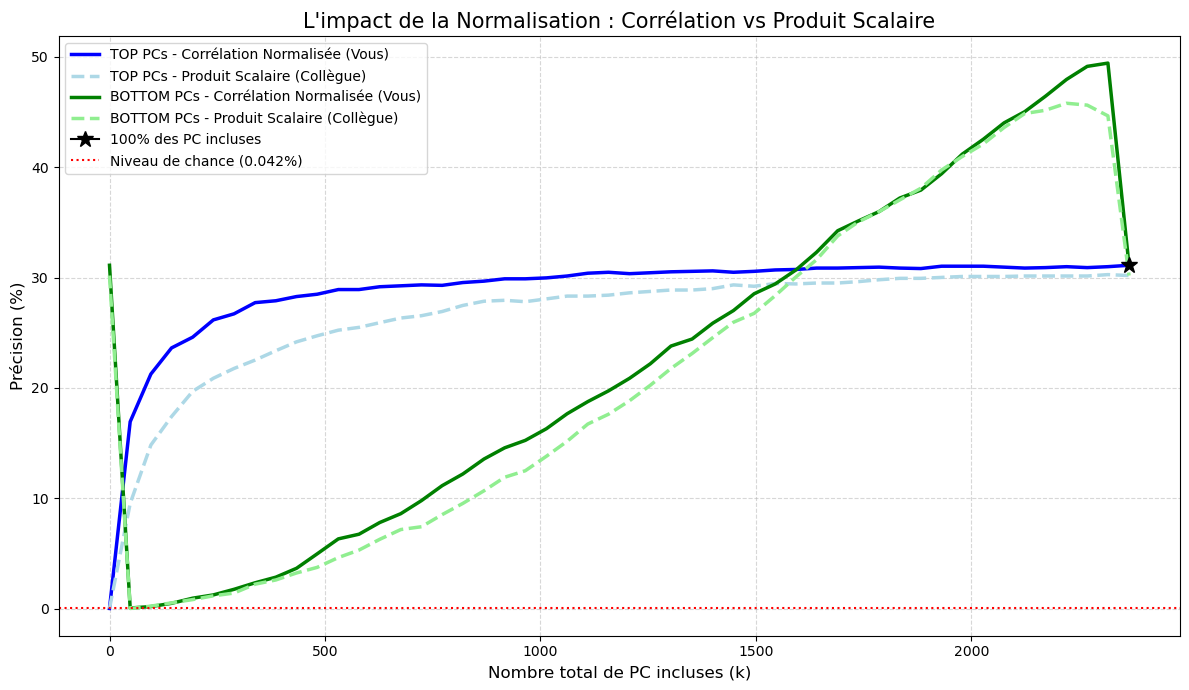

Calcul des 4 conditions en cours...


c:\Users\33673\anaconda3\envs\human_cognition\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\33673\anaconda3\envs\human_cognition\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


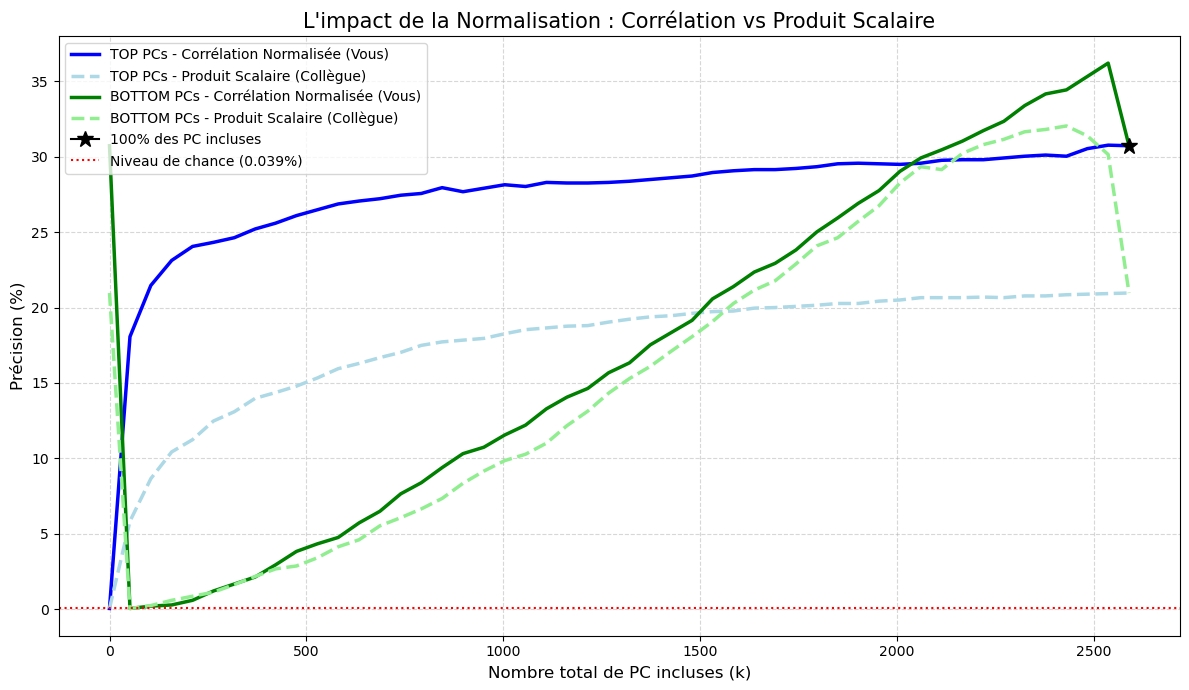

Calcul des 4 conditions en cours...


c:\Users\33673\anaconda3\envs\human_cognition\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\33673\anaconda3\envs\human_cognition\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


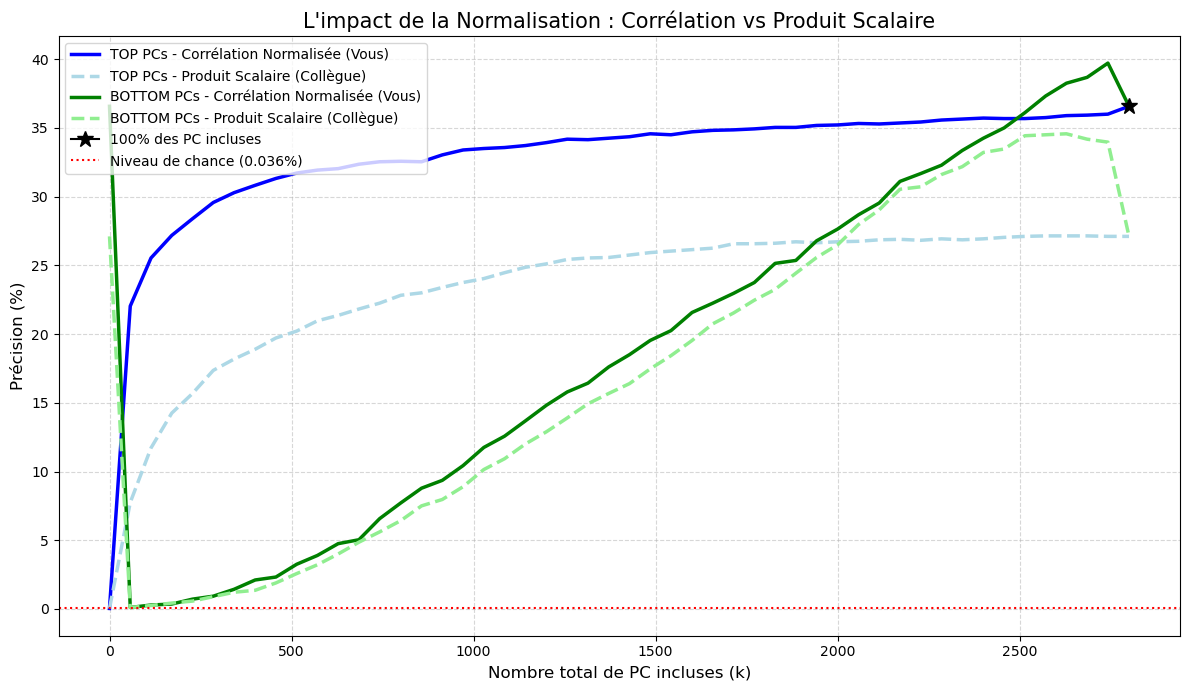

Calcul des 4 conditions en cours...


c:\Users\33673\anaconda3\envs\human_cognition\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\33673\anaconda3\envs\human_cognition\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


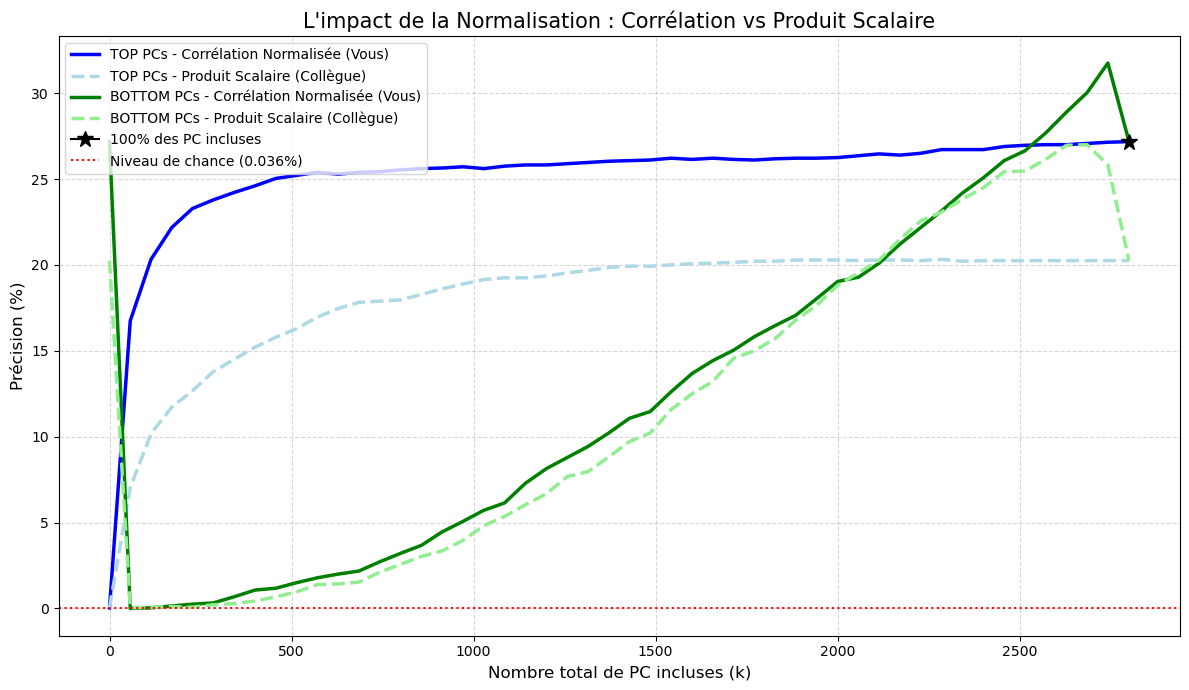

Calcul des 4 conditions en cours...


c:\Users\33673\anaconda3\envs\human_cognition\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\33673\anaconda3\envs\human_cognition\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


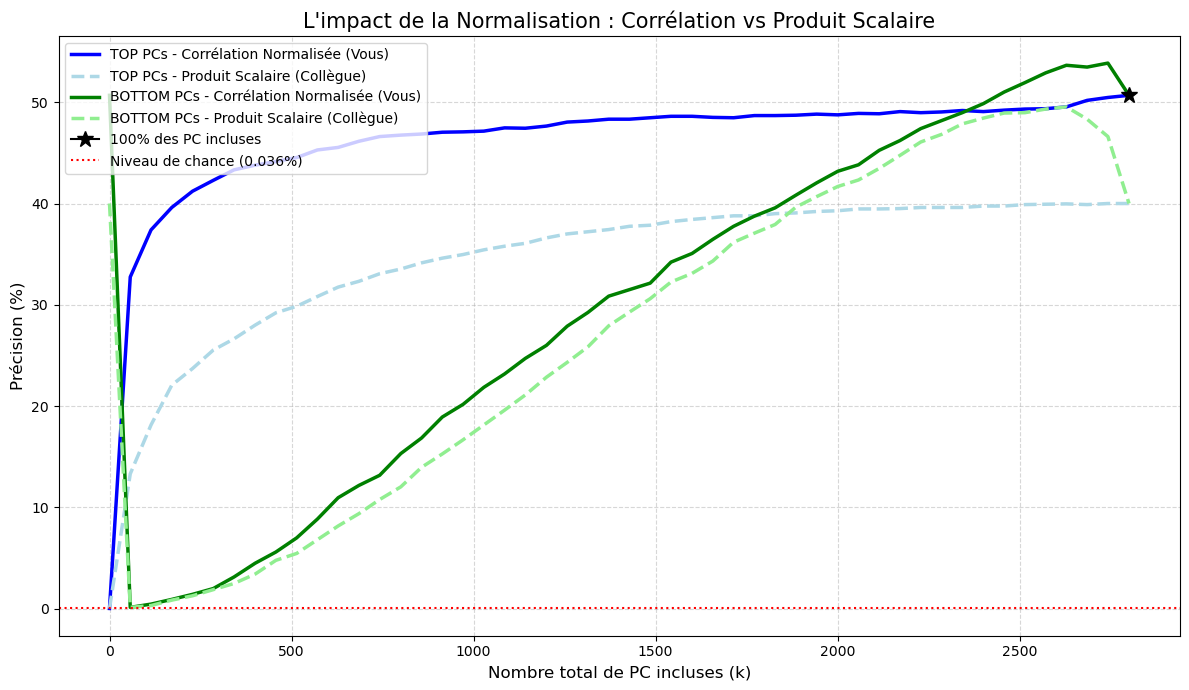

Calcul des 4 conditions en cours...


c:\Users\33673\anaconda3\envs\human_cognition\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\33673\anaconda3\envs\human_cognition\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


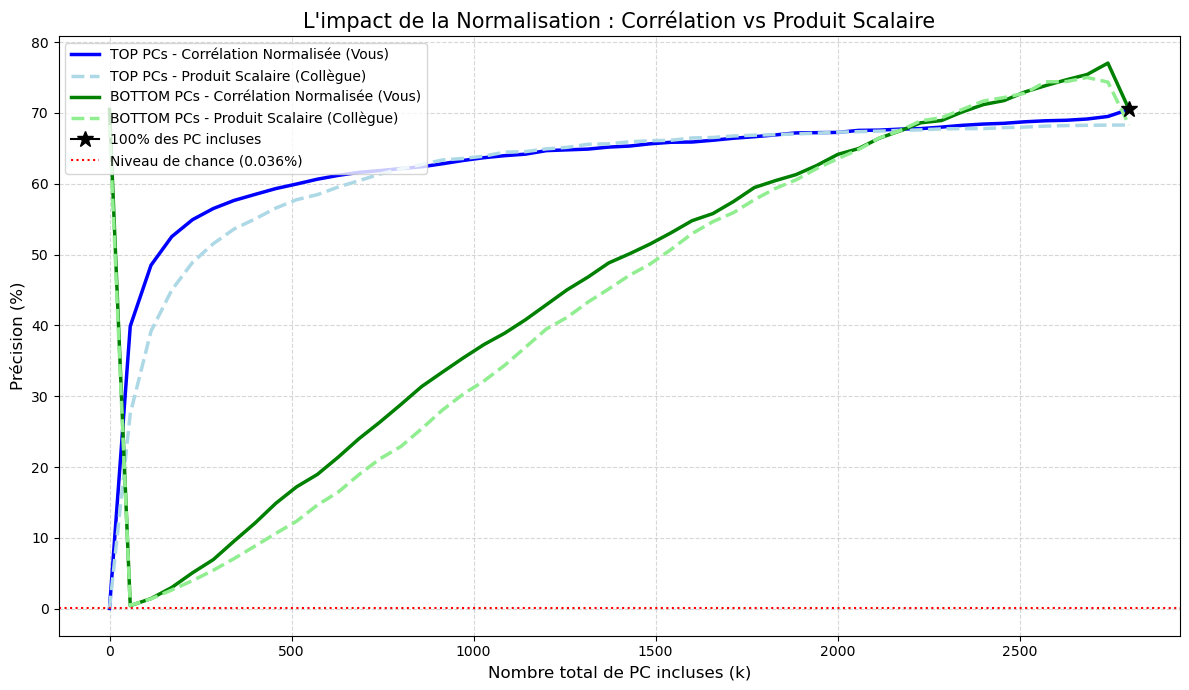

Calcul des 4 conditions en cours...


c:\Users\33673\anaconda3\envs\human_cognition\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\33673\anaconda3\envs\human_cognition\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


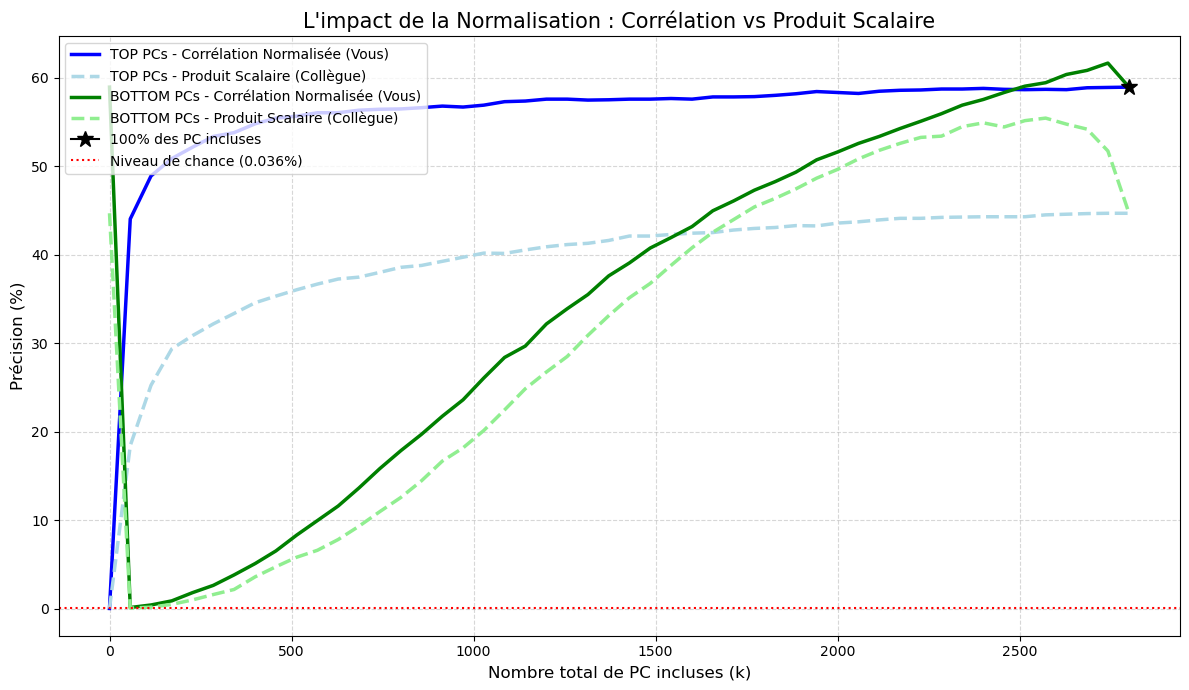

In [ ]:

for file in files:
    X1_z, X2_z, axes_bruit, train_ids, test_ids = prepare_data(file) #exemple with one mouse 
    X1_clean, X2_clean = clean_spontaneous_activity((X1_z, X2_z), axes_bruit) #clean neural data with first functions 
    variance_cvpca, pca_signal, projection_1, projection_2 = PCA_cvPCA(X1_clean, X2_clean) #perform cvPCA on the cleaned data

    # ==========================================
    # VOTRE FONCTION DE NORMALISATION
    # ==========================================
    def normalize_population_vectors(mat):
        mat_centered = mat - np.mean(mat, axis=1, keepdims=True)
        norm = np.linalg.norm(mat_centered, axis=1, keepdims=True)
        norm[norm == 0] = 1e-10
        return mat_centered / norm

    # ==========================================
    # 1. TRI CVPCA (Rappel)
    # ==========================================
    signal_var = np.sum(projection_1 * projection_2, axis=0)
    cv_order = np.argsort(signal_var)[::-1]  
    proj_1_cv = projection_1[:, cv_order]
    proj_2_cv = projection_2[:, cv_order]

    # ==========================================
    # 2. PARAMÈTRES
    # ==========================================
    n_max = proj_1_cv.shape[1]
    ks = np.unique(np.linspace(0, n_max, num=50).astype(int))
    # On s'assure que la toute dernière valeur (toutes les PC) est incluse
    if n_max not in ks:
        ks = np.append(ks, n_max)

    # Listes pour stocker les 4 résultats
    acc_norm_top = []
    acc_dot_top = []
    acc_norm_bot = []
    acc_dot_bot = []

    print("Calcul des 4 conditions en cours...")

    # ==========================================
    # 3. BOUCLE DE COMPARAISON
    # ==========================================
    for k in ks:
        # --- EXTRACTION DES PAQUETS ---
        # TOP : Les 'k' meilleures PC
        s1_top, s2_top = proj_1_cv[:, :k], proj_2_cv[:, :k]
        # BOTTOM : Les 'k' pires PC (qui finissent par inclure les meilleures à la fin)
        s1_bot, s2_bot = proj_1_cv[:, -k:], proj_2_cv[:, -k:]
        
        # --- CONDITION 1 : TOP PCs ---
        # Normalisé (Vous)
        tn_top, testn_top = normalize_population_vectors(s1_top), normalize_population_vectors(s2_top)
        acc_norm_top.append(np.mean(train_ids[np.argmax(np.dot(testn_top, tn_top.T), axis=1)] == test_ids) * 100)
        # Dot Product (Collègue)
        acc_dot_top.append(np.mean(train_ids[np.argmax(np.dot(s2_top, s1_top.T), axis=1)] == test_ids) * 100)

        # --- CONDITION 2 : BOTTOM PCs ---
        # Normalisé (Vous)
        tn_bot, testn_bot = normalize_population_vectors(s1_bot), normalize_population_vectors(s2_bot)
        acc_norm_bot.append(np.mean(train_ids[np.argmax(np.dot(testn_bot, tn_bot.T), axis=1)] == test_ids) * 100)
        # Dot Product (Collègue)
        acc_dot_bot.append(np.mean(train_ids[np.argmax(np.dot(s2_bot, s1_bot.T), axis=1)] == test_ids) * 100)


    # ==========================================
    # 4. AFFICHAGE DU GRAPHIQUE
    # ==========================================
    plt.figure(figsize=(12, 7))

    # Courbes TOP PCs (Meilleures d'abord)
    plt.plot(ks, acc_norm_top, label='TOP PCs - Corrélation Normalisée (Vous)', color='blue', linewidth=2.5)
    plt.plot(ks, acc_dot_top, label='TOP PCs - Produit Scalaire (Collègue)', color='lightblue', linewidth=2.5, linestyle='--')

    # Courbes BOTTOM PCs (Pires d'abord)
    plt.plot(ks, acc_norm_bot, label='BOTTOM PCs - Corrélation Normalisée (Vous)', color='green', linewidth=2.5)
    plt.plot(ks, acc_dot_bot, label='BOTTOM PCs - Produit Scalaire (Collègue)', color='lightgreen', linewidth=2.5, linestyle='--')

    # Marqueur de fin (où tout le monde se rejoint)
    plt.plot(n_max, acc_norm_top[-1], marker='*', color='black', markersize=12, label='100% des PC incluses')

    # Ligne de chance
    chance_level = (1 / len(test_ids)) * 100
    plt.axhline(chance_level, color='red', linestyle=':', label=f'Niveau de chance ({chance_level:.3f}%)')

    plt.title("L'impact de la Normalisation : Corrélation vs Produit Scalaire", fontsize=15)
    plt.xlabel("Nombre total de PC incluses (k)", fontsize=12)
    plt.ylabel("Précision (%)", fontsize=12)
    plt.legend(loc='upper left', fontsize=10)
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

Calcul des précisions comparées en cours...


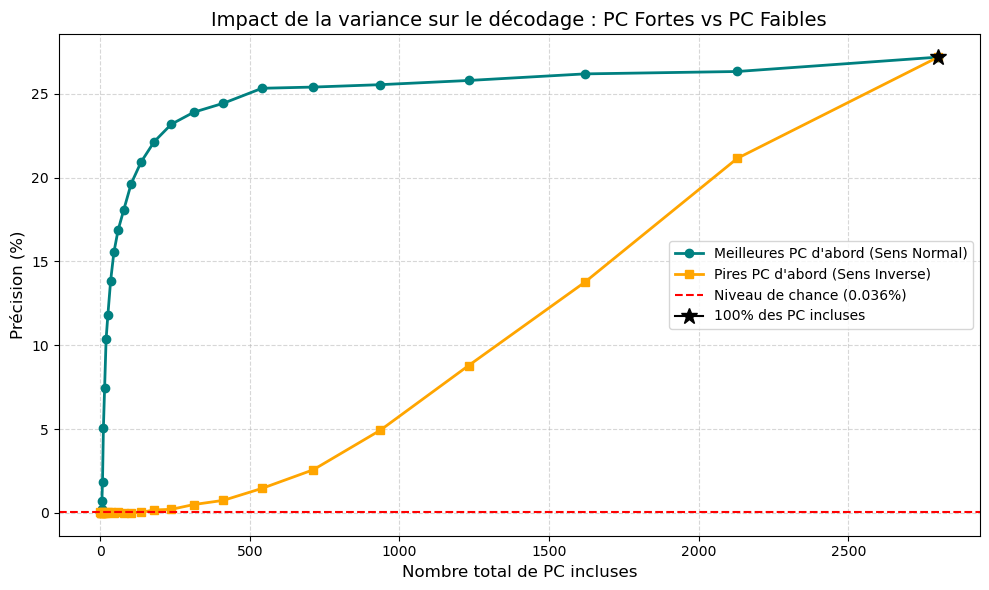

In [45]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# FONCTION DE NORMALISATION
# ==========================================
def normalize_population_vectors(mat):
    mat_centered = mat - np.mean(mat, axis=1, keepdims=True)
    norm = np.linalg.norm(mat_centered, axis=1, keepdims=True)
    norm[norm == 0] = 1e-10
    return mat_centered / norm

# ==========================================
# PARAMÈTRES
# ==========================================
n_max = projection_1.shape[1]
# On génère des dimensions à tester (échelle log) et on s'assure d'inclure le max
dimensions_a_tester = np.unique(np.logspace(0, np.log10(n_max), num=30, dtype=int))
if n_max not in dimensions_a_tester:
    dimensions_a_tester = np.append(dimensions_a_tester, n_max)

accs_most_variance = []
accs_least_variance = []

print("Calcul des précisions comparées en cours...")

# ==========================================
# BOUCLE DE DÉCODAGE
# ==========================================
for dim in dimensions_a_tester:
    # 1. SENS NORMAL : De la PC 1 à PC 'dim' (Plus grande variance)
    train_best = normalize_population_vectors(projection_1[:, :dim])
    test_best = normalize_population_vectors(projection_2[:, :dim])
    
    corr_best = np.dot(test_best, train_best.T)
    preds_best = train_ids[np.argmax(corr_best, axis=1)]
    acc_best = np.sum(preds_best == test_ids) / len(test_ids)
    accs_most_variance.append(acc_best * 100)
    
    # 2. SENS INVERSE : Les 'dim' dernières PC (Plus petite variance)
    # L'indexation [-dim:] prend les 'dim' dernières colonnes
    train_worst = normalize_population_vectors(projection_1[:, -dim:])
    test_worst = normalize_population_vectors(projection_2[:, -dim:])
    
    corr_worst = np.dot(test_worst, train_worst.T)
    preds_worst = train_ids[np.argmax(corr_worst, axis=1)]
    acc_worst = np.sum(preds_worst == test_ids) / len(test_ids)
    accs_least_variance.append(acc_worst * 100)

# ==========================================
# AFFICHAGE DU GRAPHIQUE
# ==========================================
plt.figure(figsize=(10, 6))

# Courbe "Top PCs"
plt.plot(dimensions_a_tester, accs_most_variance, marker='o', color='teal', 
         linewidth=2, label='Meilleures PC d\'abord (Sens Normal)')

# Courbe "Bottom PCs"
plt.plot(dimensions_a_tester, accs_least_variance, marker='s', color='orange', 
         linewidth=2, label='Pires PC d\'abord (Sens Inverse)')

# Ligne du niveau de chance
chance_level = (1 / len(test_ids)) * 100
plt.axhline(chance_level, color='red', linestyle='--', label=f'Niveau de chance ({chance_level:.3f}%)')

# On force les deux axes à se croiser parfaitement à la fin
plt.plot(n_max, accs_most_variance[-1], marker='*', color='black', markersize=12, label='100% des PC incluses')

plt.title("Impact de la variance sur le décodage : PC Fortes vs PC Faibles", fontsize=14)
plt.xlabel("Nombre total de PC incluses", fontsize=12)
plt.ylabel("Précision (%)", fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
def PC_results_per_mouse(N_components=None, resolution=50):
    all_PC_results = []
    for file in files:
        # 1. Préparation et nettoyage (identique)
        X1_z, X2_z, axes_bruit, train_ids, test_ids = prepare_data(file)
        X1_clean, X2_clean = clean_spontaneous_activity((X1_z, X2_z), axes_bruit)
        n_stimuli = X1_clean.shape[0]
        
        if N_components is None:
            N_components = np.logspace(2, np.log10(n_stimuli), num=resolution, dtype=int)
            
        # 2. CALCUL DE LA PCA COMPLÈTE UNE SEULE FOIS !
        # n_components=None calcule le maximum possible de PC
        variance_cvpca, pca_signal, projection_1, projection_2 = PCA_cvPCA(X1_clean, X2_clean, n_components=None)
        
        PC_results = []
        for n in N_components:
            # 3. LE SLICING MAGIQUE
            # On ne garde que les 'n' premières colonnes (les 'n' premières PC)
            proj_1_slice = projection_1[:, :n]
            proj_2_slice = projection_2[:, :n]
            
            # 4. Décodage sur le sous-ensemble
            precision_PC = decoder_nearest_neighbor_PC(proj_1_slice, proj_2_slice, train_ids, test_ids)
            PC_results.append(precision_PC)
            
        all_PC_results.append(PC_results)
        
    return all_PC_results
global_PC_results = PC_results_per_mouse(N_components=np.linspace(1, 2200, num=100, dtype=int))

Souris traitée. Précision max atteinte : 31.78%
Souris traitée. Précision max atteinte : 27.61%
Souris traitée. Précision max atteinte : 36.29%
Souris traitée. Précision max atteinte : 29.25%
Souris traitée. Précision max atteinte : 48.39%
Souris traitée. Précision max atteinte : 71.75%
Souris traitée. Précision max atteinte : 52.75%


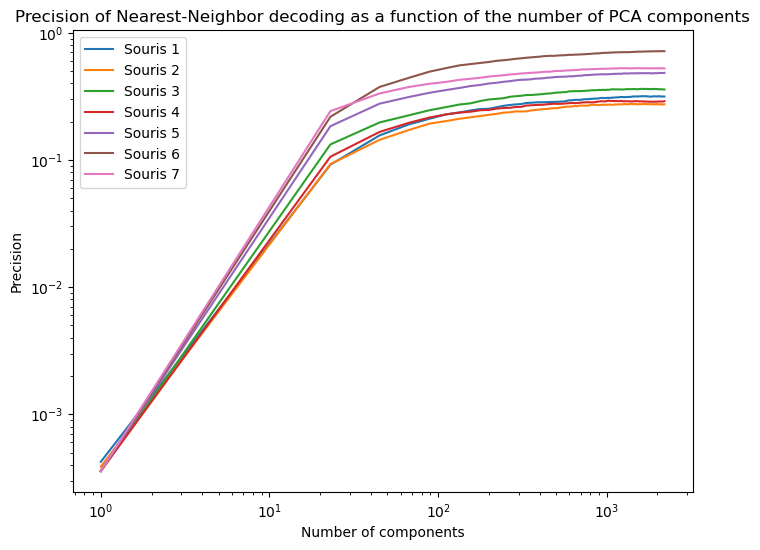

In [12]:
N_components=np.linspace(1, 2200, num=100, dtype=int)
plt.figure(figsize=(8, 6))
for i, PC_results in enumerate(global_PC_results):
    plt.loglog(N_components, PC_results, label=f'Souris {i+1}')
plt.xlabel('Number of components')
plt.ylabel('Precision')
plt.title('Precision of Nearest-Neighbor decoding as a function of the number of PCA components')
plt.legend()

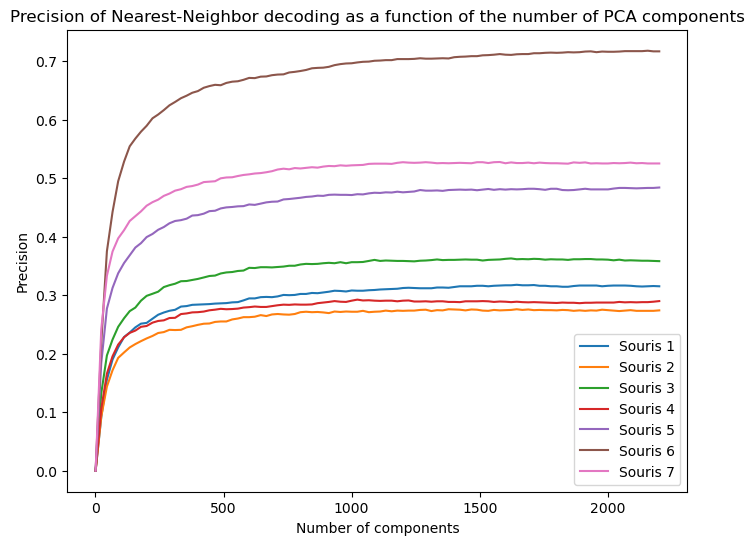

In [13]:
plt.figure(figsize=(8, 6))
for i, PC_results in enumerate(global_PC_results):
    plt.plot(N_components, PC_results, label=f'Souris {i+1}')
plt.xlabel('Number of components')
plt.ylabel('Precision')
plt.title('Precision of Nearest-Neighbor decoding as a function of the number of PCA components')
plt.savefig('precision_vs_components_linear.pdf', dpi=300)
plt.legend()

Analyse de l'impact du nombre de présentations en cours...


C:\Users\33673\AppData\Local\Temp\ipykernel_9232\1076811943.py:102: RuntimeWarning: Mean of empty slice
  moyennes = [np.nanmean(resultats_par_groupe[c]) for c in categories_presentation]
c:\Users\33673\anaconda3\envs\human_cognition\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


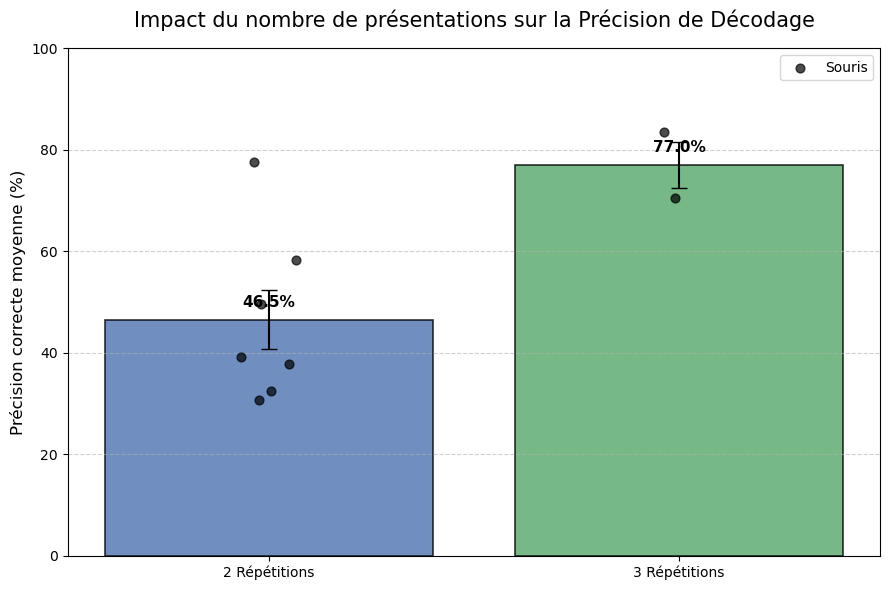

In [42]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. FONCTION DE PRÉPARATION (avec ajout des counts)
# ==========================================
def prepare_data_with_counts(mat):
    data = sio.loadmat(mat)
    reponses_neuronales = data['stim'][0]['resp'][0] 
    identites_stimuli = data['stim'][0]['istim'][0].flatten()

    # Nettoyage spontané
    masque_spontane = identites_stimuli > 2800 
    X_spont = reponses_neuronales[masque_spontane]
    scaler = StandardScaler()
    X_spont_z = scaler.fit_transform(X_spont) 
    pca_spont = PCA(n_components=32)
    pca_spont.fit(X_spont_z) 
    axes_bruit = pca_spont.components_ 

    masque_images = identites_stimuli <= 2800
    ids_valides = identites_stimuli[masque_images] 
    reponses_valides = reponses_neuronales[masque_images]
    reponses_valides_z = scaler.transform(reponses_valides) 

    unique_ids, counts = np.unique(ids_valides, return_counts=True)
    stimuli_communs = unique_ids[counts >= 2]
    
    # ON RÉCUPÈRE LE NOMBRE DE PRÉSENTATIONS POUR CHAQUE IMAGE GARDÉE
    counts_communs = counts[counts >= 2] 
    
    X1_list, X2_list, final_ids = [], [], []
    
    for stim_id in stimuli_communs:
        all_indices = np.where(ids_valides == stim_id)[0]
        X1_list.append(reponses_valides_z[all_indices[0]])
        mean_of_others = np.mean(reponses_valides_z[all_indices[1:]], axis=0)
        X2_list.append(mean_of_others)
        final_ids.append(stim_id)
        
    return np.array(X1_list), np.array(X2_list), axes_bruit, np.array(final_ids), counts_communs

# ==========================================
# 2. FONCTION DE NORMALISATION
# ==========================================
def normalize_population_vectors(mat):
    mat_centered = mat - np.mean(mat, axis=1, keepdims=True)
    norm = np.linalg.norm(mat_centered, axis=1, keepdims=True)
    norm[norm == 0] = 1e-10
    return mat_centered / norm

# ==========================================
# 3. ANALYSE SUR TOUTES LES SOURIS
# ==========================================
print("Analyse de l'impact du nombre de présentations en cours...")

# Dictionnaires pour stocker les précisions (On groupe 4 et + ensemble)
categories_presentation = [2, 3, 4] 
resultats_par_groupe = {2: [], 3: [], 4: []}

for i, file in enumerate(files):
    X1_z, X2_z, axes_bruit, final_ids, counts_communs = prepare_data_with_counts(file)
    
    # Nettoyage du bruit spontané
    proj_bruit_1 = np.dot(X1_z, axes_bruit.T)
    proj_bruit_2 = np.dot(X2_z, axes_bruit.T)
    X1_clean = X1_z - np.dot(proj_bruit_1, axes_bruit)
    X2_clean = X2_z - np.dot(proj_bruit_2, axes_bruit)
    
    # Décodage (On utilise directement les données propres sans réduire par PCA, 
    # car on veut l'accuracy max pour analyser le rôle des répétitions)
    train_norm = normalize_population_vectors(X1_clean)
    test_norm = normalize_population_vectors(X2_clean)
    corr = np.dot(test_norm, train_norm.T)
    preds = final_ids[np.argmax(corr, axis=1)]
    
    # Vecteur booléen : Vrai si bien décodé, Faux sinon
    is_correct = (preds == final_ids)
    
    # On plafonne les occurences à 4 pour regrouper "4 et +"
    counts_plafond = np.clip(counts_communs, 2, 4)
    
    # Pour cette souris, on calcule l'accuracy pour chaque catégorie
    for cat in categories_presentation:
        masque_cat = (counts_plafond == cat)
        if np.sum(masque_cat) > 0: # Si la souris a bien des images vues 'cat' fois
            acc_moyenne = np.mean(is_correct[masque_cat]) * 100
            resultats_par_groupe[cat].append(acc_moyenne)
        else:
            resultats_par_groupe[cat].append(np.nan) # Pas de données pour cette catégorie

# ==========================================
# 4. AFFICHAGE DU BAR PLOT
# ==========================================
labels = ['2 Répétitions', '3 Répétitions', '4 Répétitions ou +']
couleurs = ['#4C72B0', '#55A868', '#C44E52']

# Calcul des moyennes et erreurs types (SEM) en ignorant les potentiels NaN
moyennes = [np.nanmean(resultats_par_groupe[c]) for c in categories_presentation]
sems = [np.nanstd(resultats_par_groupe[c]) / np.sqrt(np.sum(~np.isnan(resultats_par_groupe[c]))) for c in categories_presentation]

plt.figure(figsize=(9, 6))

# Tracé des barres (moyenne de l'espèce)
barres = plt.bar(labels, moyennes, yerr=sems, capsize=6, color=couleurs, alpha=0.8, edgecolor='black', linewidth=1.2)

# Ajout des points individuels (Scatter plot des 7 souris par dessus)
for idx, cat in enumerate(categories_presentation):
    valeurs_souris = np.array(resultats_par_groupe[cat])
    # On filtre les NaN pour l'affichage
    valeurs_valides = valeurs_souris[~np.isnan(valeurs_souris)]
    
    # Ajout d'un petit "jitter" (bruit aléatoire sur X) pour que les points ne se superposent pas
    x_jitter = np.random.normal(idx, 0.04, size=len(valeurs_valides))
    plt.scatter(x_jitter, valeurs_valides, color='black', alpha=0.7, zorder=3, s=40, label='Souris' if idx==0 else "")

# Esthétique
plt.title("Impact du nombre de présentations sur la Précision de Décodage", fontsize=15, pad=15)
plt.ylabel("Précision correcte moyenne (%)", fontsize=12)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.6, zorder=0)

# Ajout de la valeur textuelle au dessus de chaque barre
for i, rect in enumerate(barres):
    hauteur = rect.get_height()
    plt.text(rect.get_x() + rect.get_width()/2., hauteur + 2,
             f'{hauteur:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.legend()
plt.tight_layout()
plt.show()

Recherche de l'accuracy MAX via PCA en cours...


C:\Users\33673\AppData\Local\Temp\ipykernel_9232\3928903500.py:114: RuntimeWarning: Mean of empty slice
  moyennes = [np.nanmean(resultats_par_groupe[c]) for c in categories_presentation]
c:\Users\33673\anaconda3\envs\human_cognition\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


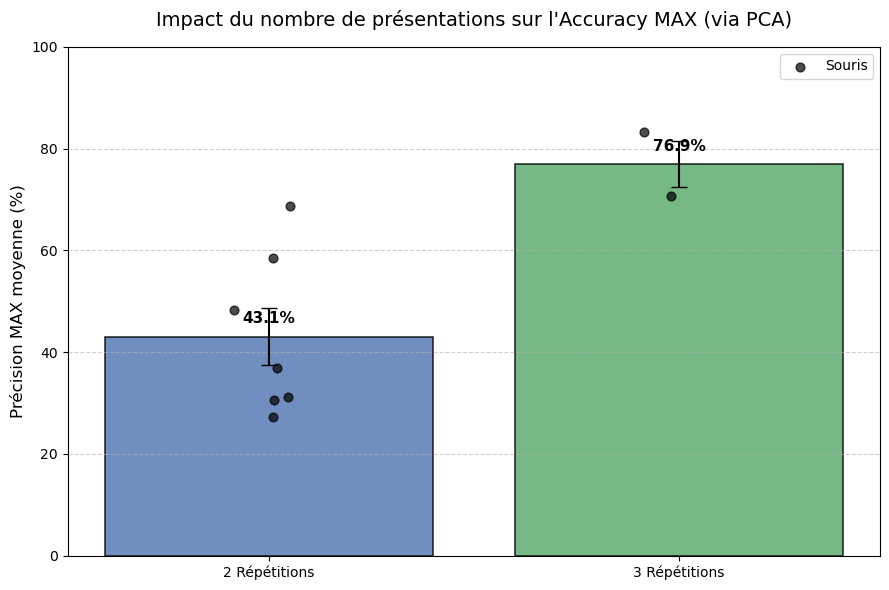

In [44]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. FONCTION DE PRÉPARATION (avec counts)
# ==========================================
def prepare_data_with_counts(mat):
    data = sio.loadmat(mat)
    reponses_neuronales = data['stim'][0]['resp'][0] 
    identites_stimuli = data['stim'][0]['istim'][0].flatten()

    # Nettoyage spontané
    masque_spontane = identites_stimuli > 2800 
    X_spont = reponses_neuronales[masque_spontane]
    scaler = StandardScaler()
    X_spont_z = scaler.fit_transform(X_spont) 
    pca_spont = PCA(n_components=32)
    pca_spont.fit(X_spont_z) 
    axes_bruit = pca_spont.components_ 

    masque_images = identites_stimuli <= 2800
    ids_valides = identites_stimuli[masque_images] 
    reponses_valides = reponses_neuronales[masque_images]
    reponses_valides_z = scaler.transform(reponses_valides) 

    unique_ids, counts = np.unique(ids_valides, return_counts=True)
    stimuli_communs = unique_ids[counts >= 2]
    counts_communs = counts[counts >= 2] 
    
    X1_list, X2_list, final_ids = [], [], []
    
    for stim_id in stimuli_communs:
        all_indices = np.where(ids_valides == stim_id)[0]
        X1_list.append(reponses_valides_z[all_indices[0]])
        mean_of_others = np.mean(reponses_valides_z[all_indices[1:]], axis=0)
        X2_list.append(mean_of_others)
        final_ids.append(stim_id)
        
    return np.array(X1_list), np.array(X2_list), axes_bruit, np.array(final_ids), counts_communs

# ==========================================
# 2. FONCTION DE NORMALISATION
# ==========================================
def normalize_population_vectors(mat):
    mat_centered = mat - np.mean(mat, axis=1, keepdims=True)
    norm = np.linalg.norm(mat_centered, axis=1, keepdims=True)
    norm[norm == 0] = 1e-10
    return mat_centered / norm

# ==========================================
# 3. ANALYSE SUR TOUTES LES SOURIS (MODIFIÉE POUR PCA)
# ==========================================
print("Recherche de l'accuracy MAX via PCA en cours...")

categories_presentation = [2, 3, 4] 
resultats_par_groupe = {2: [], 3: [], 4: []}

for i, file in enumerate(files):
    X1_z, X2_z, axes_bruit, final_ids, counts_communs = prepare_data_with_counts(file)
    
    # a. Nettoyage du bruit spontané
    proj_bruit_1 = np.dot(X1_z, axes_bruit.T)
    proj_bruit_2 = np.dot(X2_z, axes_bruit.T)
    X1_clean = X1_z - np.dot(proj_bruit_1, axes_bruit)
    X2_clean = X2_z - np.dot(proj_bruit_2, axes_bruit)
    
    # b. PCA sur les données nettoyées
    pca = PCA()
    proj_1 = pca.fit_transform(X1_clean)
    proj_2 = pca.transform(X2_clean)
    
    # c. Balayage des dimensions PC pour trouver le max
    n_max = proj_1.shape[1]
    # On teste ~40 paliers de dimensions (échelle log pour être rapide et précis)
    ks = np.unique(np.logspace(0, np.log10(n_max), num=40).astype(int))
    
    # Dictionnaire temporaire pour retenir le MAX de cette souris
    max_acc_souris = {2: 0, 3: 0, 4: 0}
    counts_plafond = np.clip(counts_communs, 2, 4)
    
    for k in ks:
        # Décodage avec les k premières PC
        train_norm = normalize_population_vectors(proj_1[:, :k])
        test_norm = normalize_population_vectors(proj_2[:, :k])
        corr = np.dot(test_norm, train_norm.T)
        preds = final_ids[np.argmax(corr, axis=1)]
        is_correct = (preds == final_ids)
        
        # Mise à jour de l'accuracy max pour chaque catégorie
        for cat in categories_presentation:
            masque_cat = (counts_plafond == cat)
            if np.sum(masque_cat) > 0:
                acc_k = np.mean(is_correct[masque_cat]) * 100
                if acc_k > max_acc_souris[cat]:
                    max_acc_souris[cat] = acc_k
                    
    # Stockage du meilleur score trouvé pour la souris finale
    for cat in categories_presentation:
        if np.sum(counts_plafond == cat) > 0:
            resultats_par_groupe[cat].append(max_acc_souris[cat])
        else:
            resultats_par_groupe[cat].append(np.nan)

# ==========================================
# 4. AFFICHAGE DU BAR PLOT
# ==========================================
labels = ['2 Répétitions', '3 Répétitions', '4 Répétitions ou +']
couleurs = ['#4C72B0', '#55A868', '#C44E52']

# Calcul des moyennes et erreurs types
moyennes = [np.nanmean(resultats_par_groupe[c]) for c in categories_presentation]
sems = [np.nanstd(resultats_par_groupe[c]) / np.sqrt(np.sum(~np.isnan(resultats_par_groupe[c]))) for c in categories_presentation]

plt.figure(figsize=(9, 6))

# Tracé des barres
barres = plt.bar(labels, moyennes, yerr=sems, capsize=6, color=couleurs, alpha=0.8, edgecolor='black', linewidth=1.2)

# Points individuels des souris
for idx, cat in enumerate(categories_presentation):
    valeurs_souris = np.array(resultats_par_groupe[cat])
    valeurs_valides = valeurs_souris[~np.isnan(valeurs_souris)]
    x_jitter = np.random.normal(idx, 0.04, size=len(valeurs_valides))
    plt.scatter(x_jitter, valeurs_valides, color='black', alpha=0.7, zorder=3, s=40, label='Souris' if idx==0 else "")

# Esthétique
plt.title("Impact du nombre de présentations sur l'Accuracy MAX (via PCA)", fontsize=14, pad=15)
plt.ylabel("Précision MAX moyenne (%)", fontsize=12)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.6, zorder=0)

for i, rect in enumerate(barres):
    hauteur = rect.get_height()
    plt.text(rect.get_x() + rect.get_width()/2., hauteur + 2,
             f'{hauteur:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.legend()
plt.tight_layout()
plt.show()